<a href="https://colab.research.google.com/github/jebunn/Neural-Network/blob/main/Problem_set_01/Problem_set1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Dataset path
DATASET_PATH = '/content/drive/MyDrive/Archive'
TRAIN_DIR = DATASET_PATH + '/train'
TEST_DIR  = DATASET_PATH + '/test'
VAL_DIR   = DATASET_PATH + '/val'

print("✅ Drive mounted!")
print(f"Train: {TRAIN_DIR}")
print(f"Test:  {TEST_DIR}")
print(f"Val:   {VAL_DIR}")

Mounted at /content/drive
✅ Drive mounted!
Train: /content/drive/MyDrive/Archive/train
Test:  /content/drive/MyDrive/Archive/test
Val:   /content/drive/MyDrive/Archive/val


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ GPU Available: {tf.config.list_physical_devices('GPU')}")

✅ TensorFlow version: 2.19.0
✅ GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Count images in each folder
for split, path in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR), ("VAL", VAL_DIR)]:
    print(f"\n📂 {split}:")
    for cls in os.listdir(path):
        cls_path = os.path.join(path, cls)
        if os.path.isdir(cls_path):
            count = len(os.listdir(cls_path))
            print(f"   {cls}: {count} images")


📂 TRAIN:
   NORMAL: 1341 images
   PNEUMONIA: 3875 images

📂 TEST:
   NORMAL: 234 images
   PNEUMONIA: 390 images

📂 VAL:
   PNEUMONIA: 8 images
   NORMAL: 8 images


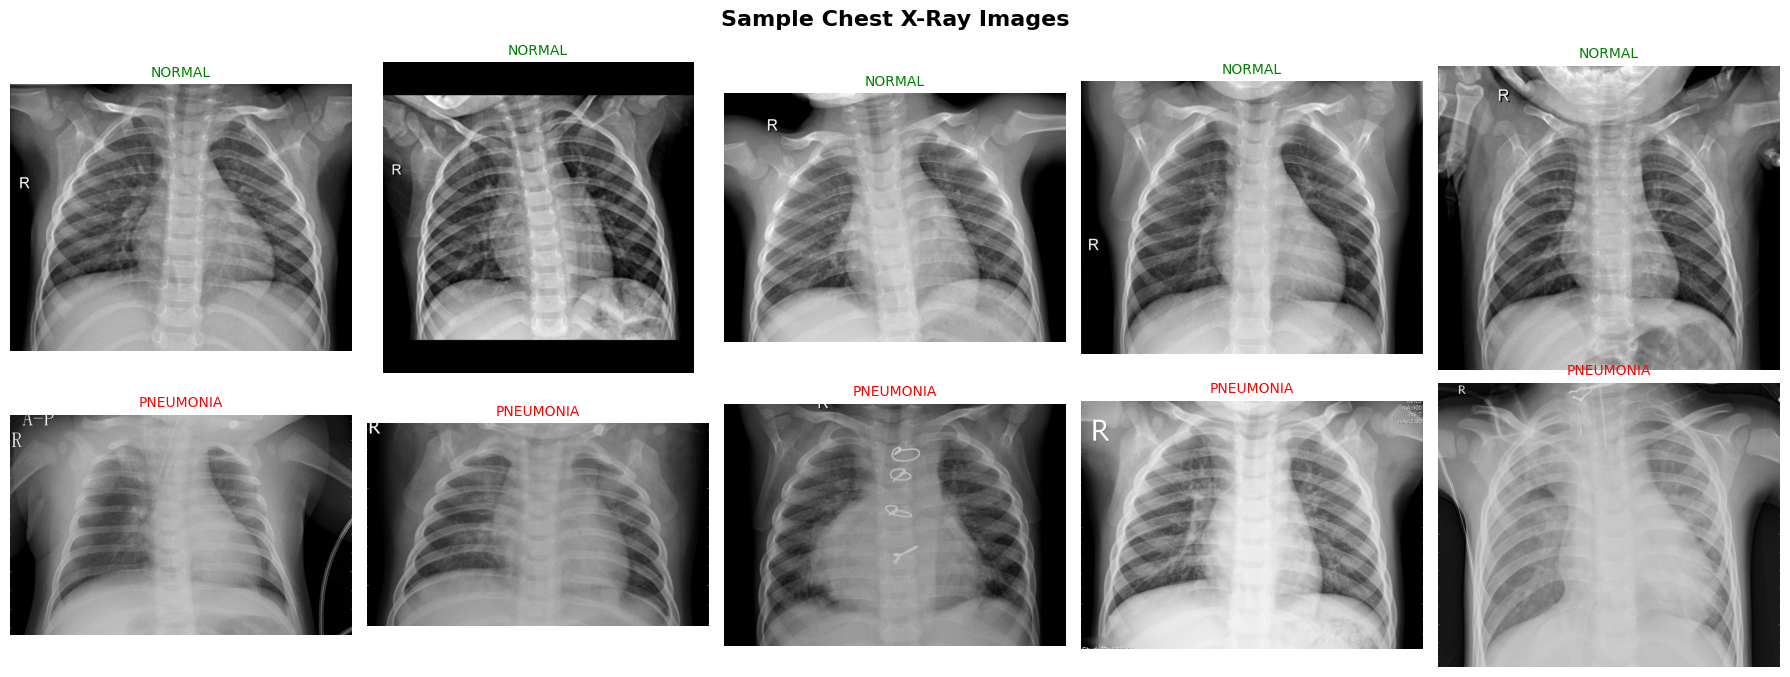

✅ Sample images displayed!


In [ ]:
import random
from PIL import Image

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle("Sample Chest X-Ray Images", fontsize=16, fontweight='bold')

for i, cls in enumerate(['NORMAL', 'PNEUMONIA']):
    cls_path = os.path.join(TRAIN_DIR, cls)
    images = random.sample(os.listdir(cls_path), 5)
    for j, img_name in enumerate(images):
        img_path = os.path.join(cls_path, img_name)
        img = Image.open(img_path).convert('RGB')
        axes[i][j].imshow(img, cmap='gray')
        axes[i][j].set_title(cls, fontsize=10,
                              color='red' if cls == 'PNEUMONIA' else 'green')
        axes[i][j].axis('off')

plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images displayed!")

In [ ]:
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

# Training data: augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Validation & Test: only rescale
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Generators
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    seed=SEED,
    shuffle=True
)

val_gen = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_gen = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print(f"\n✅ Class indices: {train_gen.class_indices}")
print(f"   Train samples : {train_gen.samples}")
print(f"   Val samples   : {val_gen.samples}")
print(f"   Test samples  : {test_gen.samples}")

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.

✅ Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}
   Train samples : 5216
   Val samples   : 16
   Test samples  : 624


In [ ]:
def build_cnn_model(input_shape=(224, 224, 3)):
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.25),

        # Block 4
        layers.Conv2D(256, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),
        layers.Dropout(0.3),

        # Classifier Head
        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')  # Binary classification
    ])
    return model

model = build_cnn_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 850,209 (3.24 MB)

 Trainable params: 847,777 (3.23 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy',
             tf.keras.metrics.AUC(name='auc'),
             tf.keras.metrics.Precision(name='precision'),
             tf.keras.metrics.Recall(name='recall')]
)
print("✅ Model compiled successfully!")

✅ Model compiled successfully!


In [ ]:
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, TensorBoard)

checkpoint = ModelCheckpoint(
    '/content/best_cnn_model.keras',
    monitor='val_auc',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callback_list = [checkpoint, early_stop, reduce_lr]
print("✅ Callbacks ready!")

✅ Callbacks ready!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

# Compute class weights (Pneumonia >> Normal in dataset)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# Train
EPOCHS = 3

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=callback_list,
    class_weight=class_weight_dict,
    verbose=1
)

print("\n✅ Training complete!")

Class weights: {0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}
Epoch 1/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.8498 - auc: 0.9335 - loss: 0.3310 - precision: 0.9690 - recall: 0.8234
Epoch 1: val_auc improved from None to 0.35156, saving model to /content/best_cnn_model.keras

Epoch 1: finished saving model to /content/best_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 820s 5s/step - accuracy: 0.8579 - auc: 0.9359 - loss: 0.3190 - precision: 0.9686 - recall: 0.8359 - val_accuracy: 0.5000 - val_auc: 0.3516 - val_loss: 2.4130 - val_precision: 0.5000 - val_recall: 1.0000 - learning_rate: 1.0000e-04
Epoch 2/3
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 781ms/step - accuracy: 0.8735 - auc: 0.9467 - loss: 0.2951 - precision: 0.9682 - recall: 0.8554
Epoch 2: val_auc improved from 0.35156 to 0.50000, saving model to /content/best_cnn_model.keras

Epoch 2: finished saving model to /content/best_cnn_model.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 128s 783ms/step - accuracy: 0.8

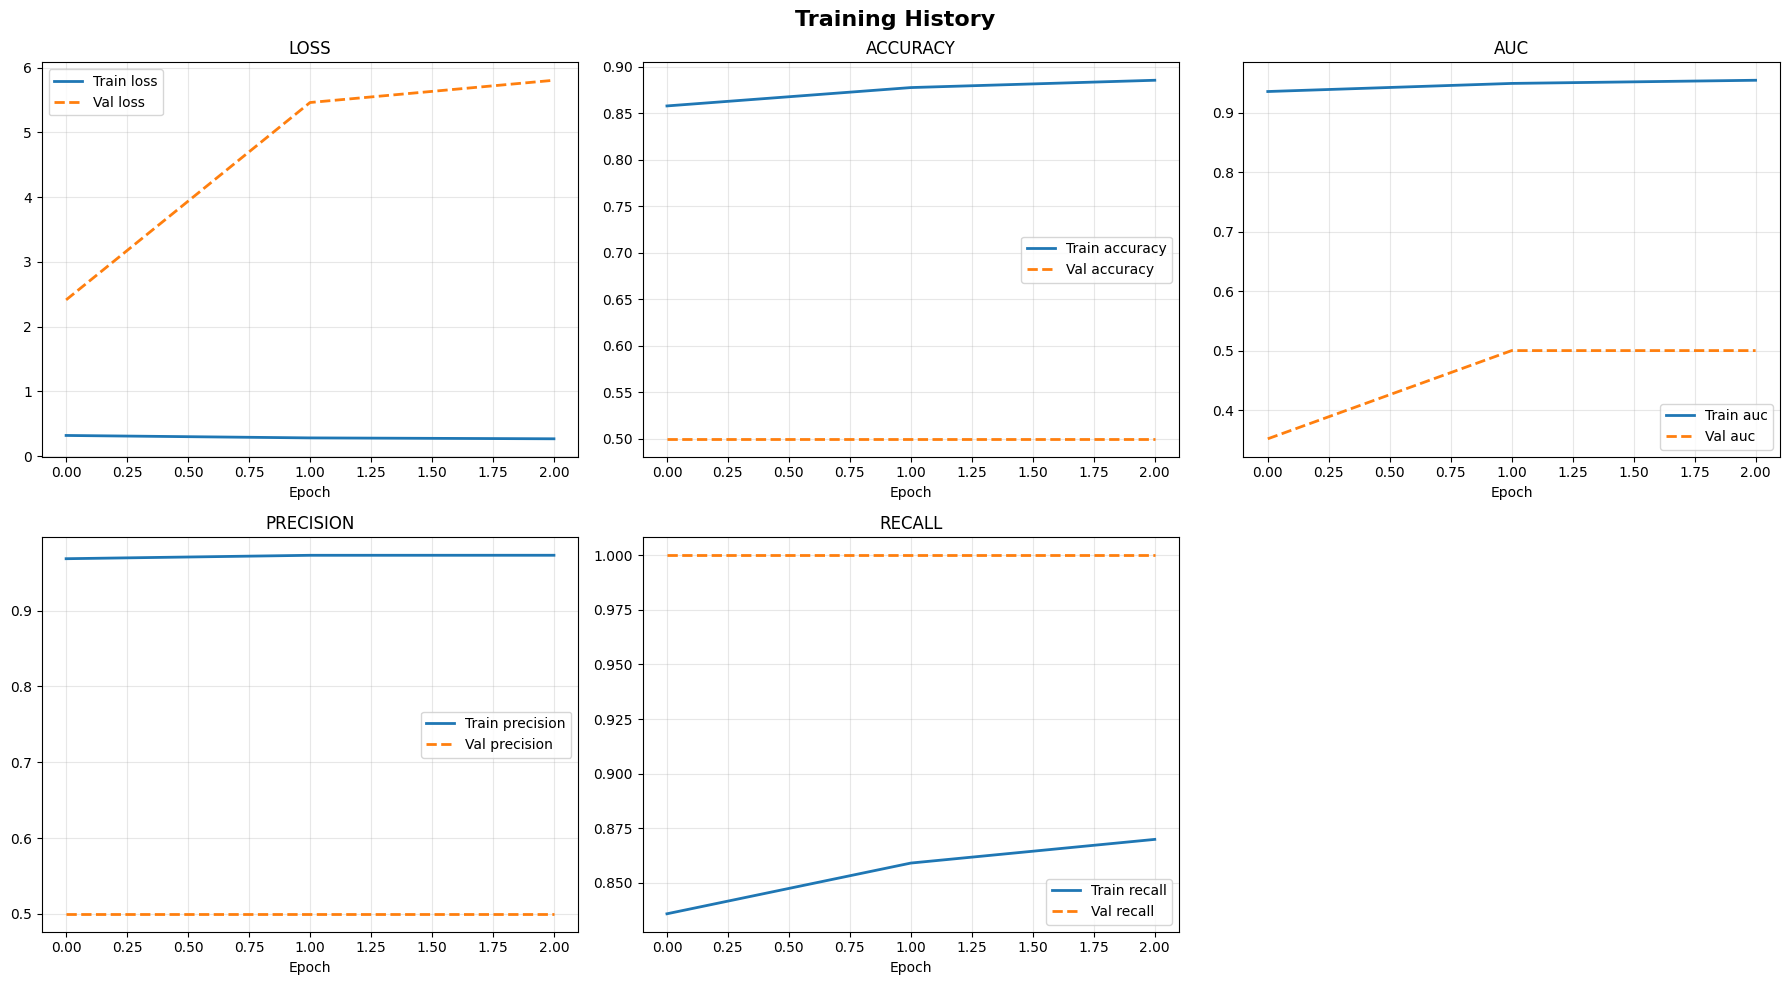

✅ Training plots saved!


In [ ]:
def plot_history(history):
    metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle('Training History', fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, metric in enumerate(metrics):
        if metric in history.history:
            axes[i].plot(history.history[metric], label=f'Train {metric}', linewidth=2)
            axes[i].plot(history.history[f'val_{metric}'], label=f'Val {metric}',
                         linewidth=2, linestyle='--')
            axes[i].set_title(metric.upper(), fontsize=12)
            axes[i].set_xlabel('Epoch')
            axes[i].legend()
            axes[i].grid(True, alpha=0.3)

    axes[-1].axis('off')
    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history)
print("✅ Training plots saved!")

In [ ]:
# Load best model
best_model = tf.keras.models.load_model('/content/best_cnn_model.keras')

# Evaluate
test_results = best_model.evaluate(test_gen, verbose=1)
metrics_names = best_model.metrics_names

print("\n📊 Test Set Results:")
print("-" * 35)
for name, val in zip(metrics_names, test_results):
    print(f"  {name.upper():<15}: {val:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 169s 9s/step - accuracy: 0.6250 - auc: 0.5000 - loss: 4.2985 - precision: 0.6250 - recall: 1.0000

📊 Test Set Results:
-----------------------------------
  LOSS           : 4.2985
  COMPILE_METRICS: 0.6250


20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 620ms/step

📋 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.00      0.00      0.00       234
   PNEUMONIA       0.62      1.00      0.77       390

    accuracy                           0.62       624
   macro avg       0.31      0.50      0.38       624
weighted avg       0.39      0.62      0.48       624



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


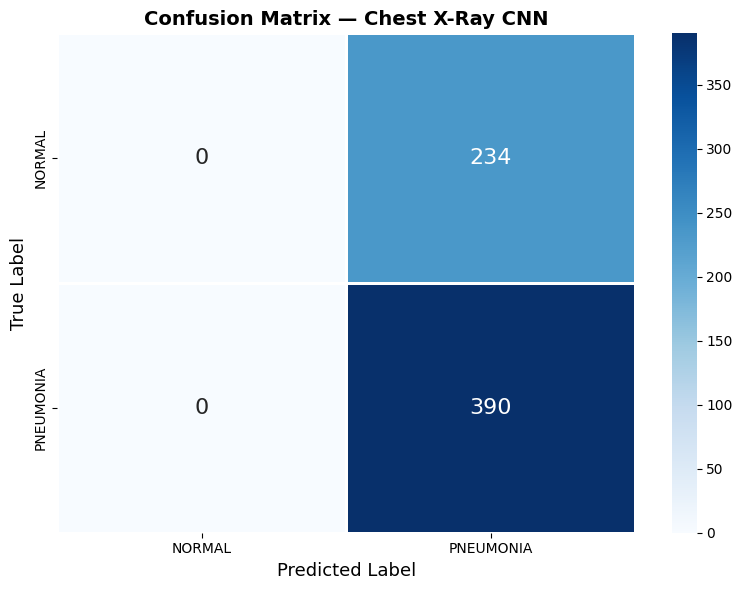

✅ Confusion matrix saved!


In [ ]:
# Predictions
test_gen.reset()
y_pred_probs = best_model.predict(test_gen, verbose=1)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = test_gen.classes

class_names = list(test_gen.class_indices.keys())

# Classification Report
print("\n📋 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=2, annot_kws={"size": 16})
ax.set_xlabel('Predicted Label', fontsize=13)
ax.set_ylabel('True Label', fontsize=13)
ax.set_title('Confusion Matrix — Chest X-Ray CNN', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

In [ ]:
import shutil

save_dir = '/content/drive/MyDrive/PneumoniaCNN_Results'
os.makedirs(save_dir, exist_ok=True)

# Copy models & plots
for f in ['/content/best_cnn_model.keras',
          '/content/best_vgg16_model.keras',
          '/content/training_history.png',
          '/content/confusion_matrix.png',
          '/content/sample_images.png']:
    if os.path.exists(f):
        shutil.copy(f, save_dir)
        print(f"✅ Saved: {os.path.basename(f)}")

print(f"\n All results saved to: {save_dir}")

✅ Saved: best_cnn_model.keras
✅ Saved: training_history.png
✅ Saved: confusion_matrix.png
✅ Saved: sample_images.png

 All results saved to: /content/drive/MyDrive/PneumoniaCNN_Results
